# 04 — Exploratory Data Analysis (EDA)

## Supply Chain & Sales Analytics Dashboard

Objectif : analyser les ventes, les clients, les produits, les vendeurs, la logistique et la satisfaction client afin de préparer un dashboard Power BI et des recommandations business.

Ce notebook part du fichier `sales_featured.csv`, créé après les étapes de data cleaning et feature engineering.

## 1. Imports & chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PROCESSED = Path("../data/processed")

sales = pd.read_csv(
    DATA_PROCESSED / "sales_featured.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "shipping_limit_date",
        "review_creation_date",
        "review_answer_timestamp",
    ],
)

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,purchase_year,purchase_month,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,delivery_time_days,delivery_delay_days,approval_time_hours,shipping_time_days,total_order_value,freight_ratio,review_label,is_delayed,items_per_order
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.00,credit_card,1.00,18.12,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,"9,350.00",maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,4,2,Monday,10,8.00,-8.00,0.18,2.00,38.71,0.23,Satisfied,0,3
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.00,voucher,1.00,2.00,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,"9,350.00",maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,4,2,Monday,10,8.00,-8.00,0.18,2.00,38.71,0.23,Satisfied,0,3
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.00,voucher,1.00,18.59,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,"9,350.00",maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,4,2,Monday,10,8.00,-8.00,0.18,2.00,38.71,0.23,Satisfied,0,3
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.00,boleto,1.00,141.46,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,"31,570.00",belo horizonte,SP,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,2018,7,3,24,Tuesday,20,13.00,-6.00,30.71,0.00,141.46,0.16,Satisfied,0,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.00,credit_card,3.00,179.12,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,"14,840.00",guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.00,NaN,NaN,2018-08-18,2018-08-22 19:07:58,2018,8,3,8,Wednesday,8,9.00,-18.00,0.28,0.00,179.12,0.11,Satisfied,0,1

## 2. Vérification rapide

In [2]:
print(f"Rows: {sales.shape[0]:,}")
print(f"Columns: {sales.shape[1]:,}")

sales.info()

Rows: 119,143
Columns: 54
<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 54 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  str           
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  str  

In [3]:
sales.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,purchase_year,purchase_month,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,delivery_time_days,delivery_delay_days,approval_time_hours,shipping_time_days,total_order_value,freight_ratio,review_label,is_delayed,items_per_order
count,119143,119143,119143,119143,118966,117057,115722,119143,119143,"119,143.00",119143,119143,"118,310.00",118310,118310,118310,"118,310.00","118,310.00","119,140.00",119140,"119,140.00","119,140.00",116601,"116,601.00","116,601.00","116,601.00","118,290.00","118,290.00","118,290.00","118,290.00","118,310.00",118310,118310,118146,"118,146.00",13989,50245,118146,118146,"119,143.00","119,143.00","119,143.00","119,143.00",119143,"119,143.00","115,722.00","115,722.00","118,966.00","117,042.00","118,310.00","118,310.00",119143,"119,143.00","119,143.00"
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,96096,NaN,4119,27,NaN,32951,3095,NaN,NaN,NaN,NaN,5,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,611,23,98410,NaN,4527,36159,1208,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,NaN,NaN,NaN,NaN,NaN,9a736b248f67d166d2fbb006bcb877c3,NaN,sao paulo,SP,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,NaN,NaN,NaN,NaN,credit_card,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sao paulo,SP,eef5dbca8d37dfce6db7d7b16dd0525e,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,NaN,NaN,NaN,NaN,NaN,Monday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Satisfied,NaN,NaN
freq,63,63,115723,NaN,NaN,NaN,NaN,NaN,75,NaN,18875,50265,NaN,536,2155,NaN,NaN,NaN,NaN,87776,NaN,NaN,11988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29293,84377,63,NaN,494,259,448,NaN,NaN,NaN,NaN,NaN,19366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88662,NaN,NaN
mean,NaN,NaN,NaN,2017-12-29 18:36:13.115760,2017-12-30 04:49:18.425726,2018-01-03 08:24:34.395525,2018-01-12 20:55:38.199616,2018-01-22 15:21:10.241642,NaN,"35,033.45",NaN,NaN,1.20,NaN,NaN,2018-01-05 22:06:13.308807,120.65,20.03,1.09,NaN,2.94,172.74,NaN,48.77,785.97,2.21,"2,112.25",30.27,16.62,23.07,"24,442.41",NaN,NaN,NaN,4.02,NaN,NaN,NaN,2018-01-14 17:00:35.769302,"2,017.54",6.03,2.36,15.55,NaN,14.76,12.02,-12.05,10.58,2.35,140.68,0.21,NaN,0.06,1.67
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,NaN,"1,003.00",NaN,NaN,1.00,NaN,NaN,2016-09-19 00:15:34,0.85,0.00,1.00,NaN,0.00,0.00,NaN,5.00,4.00,1.00,0.00,7.00,2.00,6.00,"1,001.00",NaN,NaN,NaN,1.00,NaN,NaN,NaN,2016-10-07 18:32:28,"2,016.00",1.00,1.00,1.00,NaN,0.00,0.00,-147.00,0.00,-172.00,6.08,0.00,NaN,0.00,1.00
25%,NaN,NaN,NaN,2017-09-10 20:15:46,2017-09-11 15:50:48.500000,2017-09-14 19:52:12,2017-09-22 21:54:31.250000,2017-10-02 00:00:00,NaN,"11,250.00",NaN,NaN,1.00,NaN,NaN,2017-09-18 14:30:33,39.90,13.08,1.00,NaN,1.00,60.85,NaN,42.00,346.00,1.00,300.00,18.00,8.00,15.00,"6,429.00",NaN,NaN,NaN,4.00,NaN,NaN,NaN,2017-09-25 11:15:40.750000,"2,017.00",3.00,1.00,8.00,NaN,11.00,6.00,-17.00,0.22,0.00,55.24,0.12,NaN,0.00,1.00
50%,NaN,NaN,NaN,2018-01-17 11:59:12,2018-01-17 16:49:49,2018-01-23 17:03:08,2018-02-01 03:17:55,2018-02-14 00:00:00,NaN,"24,240.00",NaN,NaN,1.00,NaN,NaN,2018-01-25 04:11:15.500000,74.90,16.28,1.00,NaN,2.00,108.16,NaN,52.00,600.00,1.00,700.00,25.00,13.00,20.00,"13,660.00",NaN,NaN,NaN,5.00,NaN,NaN,NaN,2018-02-03 12:0

## 3. Executive Overview — KPI principaux

Ces KPI seront utilisés dans la première page du dashboard Power BI.

In [4]:
total_revenue = sales["total_order_value"].sum()
total_orders = sales["order_id"].nunique()
total_customers = sales["customer_unique_id"].nunique()
avg_order_value = total_revenue / total_orders
delayed_rate = sales["is_delayed"].mean() * 100
avg_review_score = sales["review_score"].mean()
avg_delivery_time = sales["delivery_time_days"].mean()

kpis = pd.DataFrame(
    {
        "KPI": [
            "Total Revenue",
            "Total Orders",
            "Total Customers",
            "Average Order Value",
            "Delayed Orders Rate",
            "Average Review Score",
            "Average Delivery Time",
        ],
        "Value": [
            total_revenue,
            total_orders,
            total_customers,
            avg_order_value,
            delayed_rate,
            avg_review_score,
            avg_delivery_time,
        ],
    }
)

kpis

,KPI,Value
0,Total Revenue,"16,643,731.30"
1,Total Orders,"99,441.00"
2,Total Customers,"96,096.00"
3,Average Order Value,167.37
4,Delayed Orders Rate,6.34
5,Average Review Score,4.02
6,Average Delivery Time,12.02


### Business interpretation

- Le chiffre d'affaires total permet d'évaluer le poids global de l'activité.
- Le nombre de commandes et de clients mesure le volume commercial.
- Le panier moyen permet d'évaluer la valeur générée par commande.
- Le taux de retard et la note moyenne mesurent la qualité opérationnelle et la satisfaction client.

## 4. Sales Analysis

### 4.1 Chiffre d'affaires mensuel

In [5]:
monthly_revenue = (
    sales.groupby(sales["order_purchase_timestamp"].dt.to_period("M"))[
        "total_order_value"
    ]
    .sum()
    .reset_index()
)

monthly_revenue["month"] = monthly_revenue["order_purchase_timestamp"].astype(str)
monthly_revenue = monthly_revenue.drop(columns="order_purchase_timestamp")

monthly_revenue.head()

,total_order_value,month
0,354.75,2016-09
1,"58,730.85",2016-10
2,19.62,2016-12
3,"148,030.11",2017-01
4,"303,648.31",2017-02


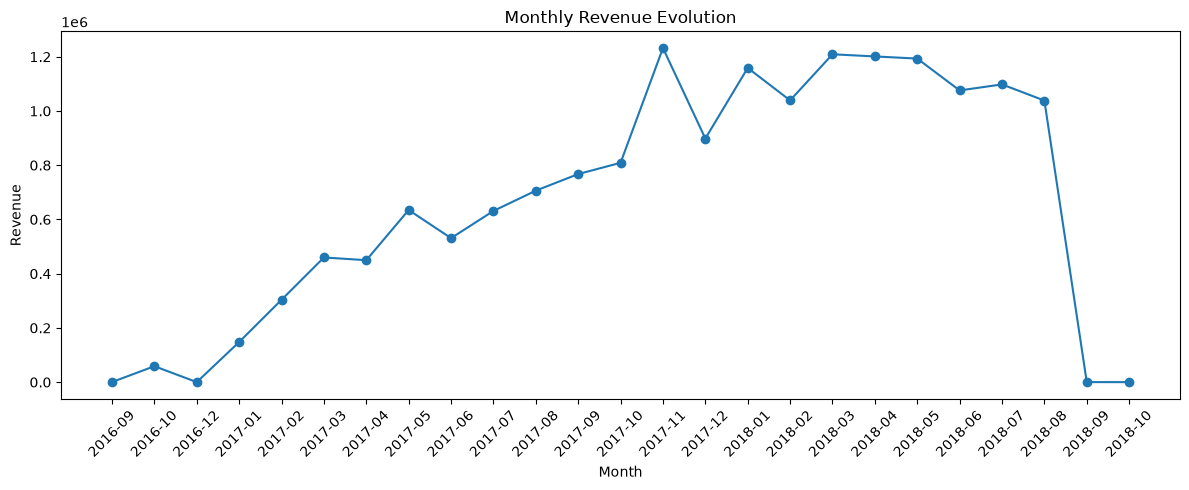

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["month"], monthly_revenue["total_order_value"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Evolution")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation

L'évolution mensuelle du chiffre d'affaires permet d'identifier les périodes de croissance, les pics saisonniers et les périodes de ralentissement.

### Business recommendation

Analyser les mois les plus performants pour comprendre si la croissance est liée à la saisonnalité, à des campagnes marketing ou à certains types de produits.

### 4.2 Nombre de commandes par mois

In [7]:
monthly_orders = (
    sales.groupby(sales["order_purchase_timestamp"].dt.to_period("M"))["order_id"]
    .nunique()
    .reset_index(name="orders")
)

monthly_orders["month"] = monthly_orders["order_purchase_timestamp"].astype(str)
monthly_orders = monthly_orders.drop(columns="order_purchase_timestamp")

monthly_orders.head()

,orders,month
0,4,2016-09
1,324,2016-10
2,1,2016-12
3,800,2017-01
4,1780,2017-02


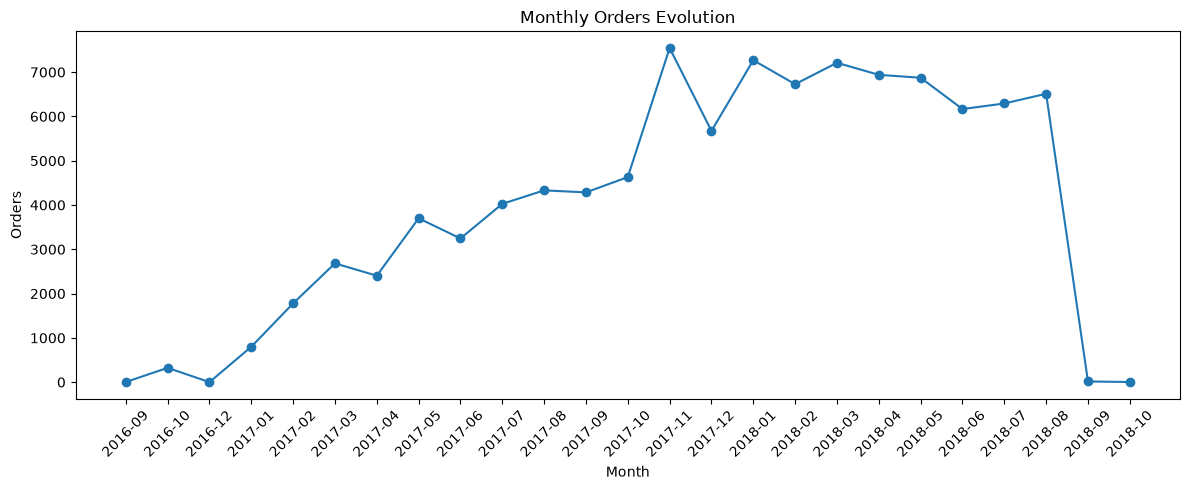

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["month"], monthly_orders["orders"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Orders Evolution")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

### 4.3 Panier moyen mensuel

In [9]:
monthly_avg_basket = (
    sales.groupby(sales["order_purchase_timestamp"].dt.to_period("M"))[
        "total_order_value"
    ]
    .mean()
    .reset_index(name="average_order_value")
)

monthly_avg_basket["month"] = monthly_avg_basket["order_purchase_timestamp"].astype(str)
monthly_avg_basket = monthly_avg_basket.drop(columns="order_purchase_timestamp")

monthly_avg_basket.head()

,average_order_value,month
0,59.12,2016-09
1,152.55,2016-10
2,19.62,2016-12
3,144.70,2017-01
4,146.48,2017-02


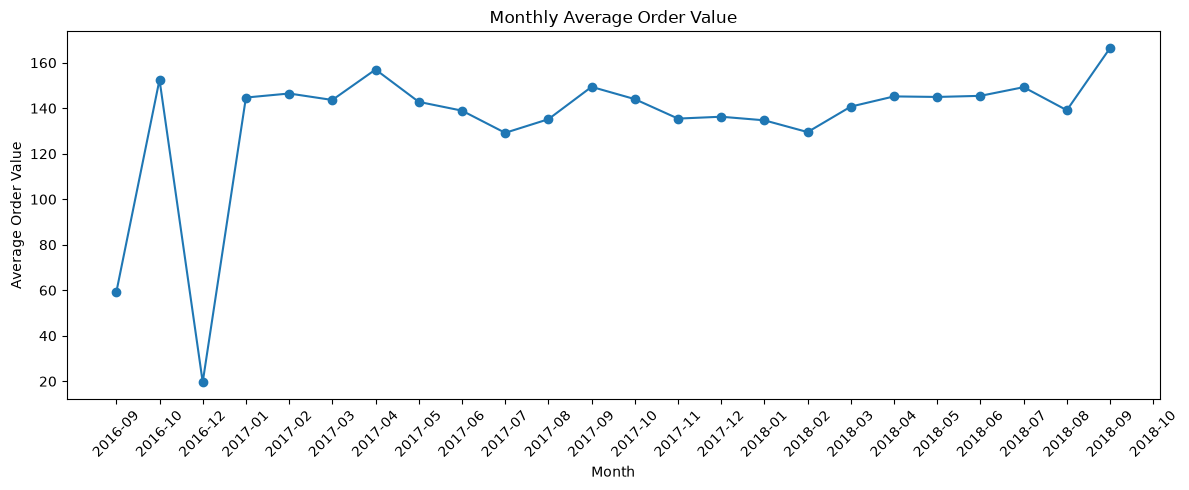

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_avg_basket["month"], monthly_avg_basket["average_order_value"], marker="o"
)
plt.xticks(rotation=45)
plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

### 4.4 Ventes par jour de la semaine

In [11]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_sales = (
    sales.groupby("purchase_weekday")["total_order_value"]
    .sum()
    .reindex(weekday_order)
    .reset_index()
)

weekday_sales

,purchase_weekday,total_order_value
0,Monday,"2,713,362.83"
1,Tuesday,"2,657,548.07"
2,Wednesday,"2,605,714.58"
3,Thursday,"2,488,992.41"
4,Friday,"2,391,727.09"
5,Saturday,"1,842,243.83"
6,Sunday,"1,944,142.49"


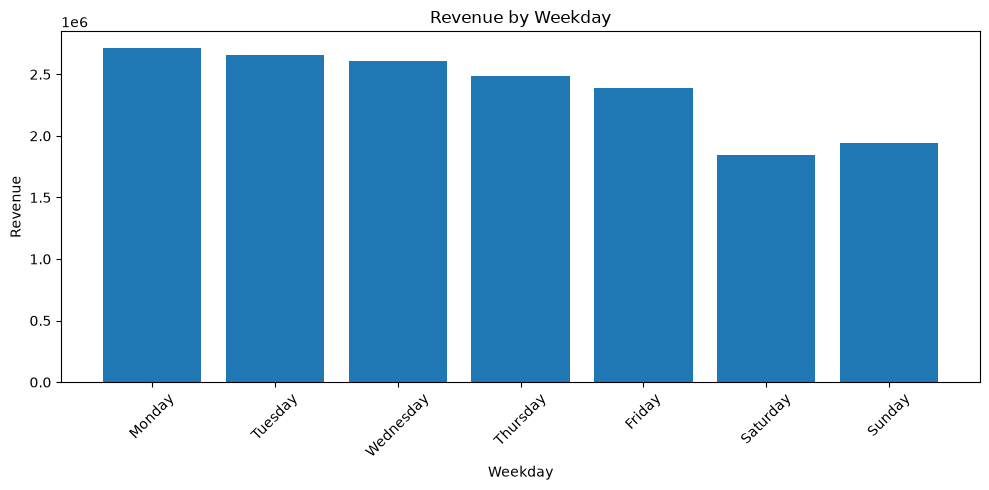

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_sales["purchase_weekday"], weekday_sales["total_order_value"])
plt.xticks(rotation=45)
plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### 4.5 Ventes par heure

In [13]:
hourly_sales = sales.groupby("purchase_hour")["total_order_value"].sum().reset_index()

hourly_sales.head()

,purchase_hour,total_order_value
0,0,"390,018.04"
1,1,"183,042.96"
2,2,"67,425.04"
3,3,"42,489.95"
4,4,"29,265.92"


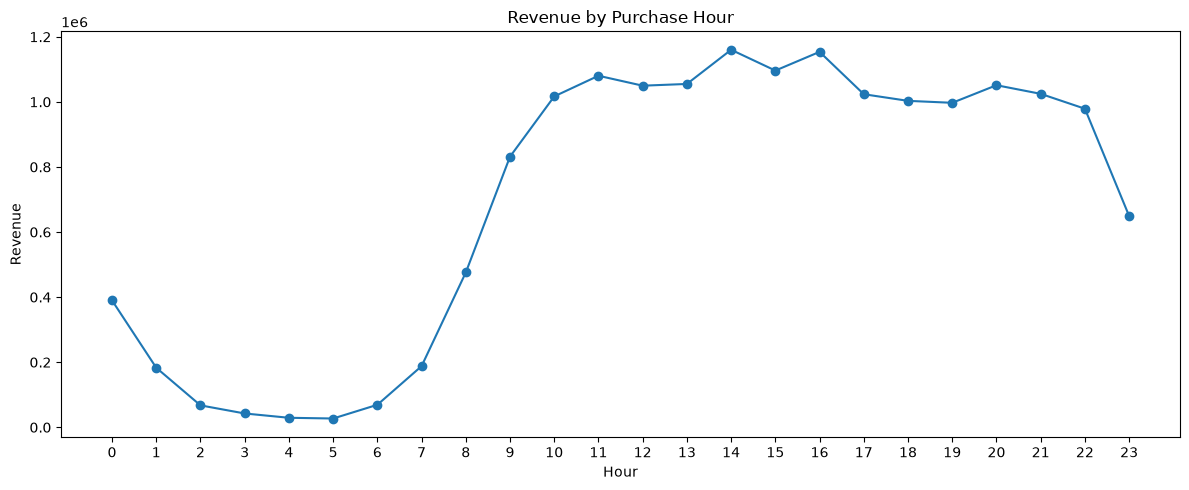

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_sales["purchase_hour"], hourly_sales["total_order_value"], marker="o")
plt.title("Revenue by Purchase Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 5. Product Analysis

### 5.1 Top 10 catégories par chiffre d'affaires

In [15]:
top_categories_revenue = (
    sales.groupby("product_category_name")["total_order_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_categories_revenue

,product_category_name,total_order_value
0,beleza_saude,"1,491,397.76"
1,relogios_presentes,"1,358,845.59"
2,cama_mesa_banho,"1,327,662.02"
3,esporte_lazer,"1,205,197.85"
4,informatica_acessorios,"1,104,362.03"
5,moveis_decoracao,"955,367.22"
6,utilidades_domesticas,"823,623.50"
7,cool_stuff,"752,702.21"
8,automotivo,"714,431.95"
9,ferramentas_jardim,"625,387.31"


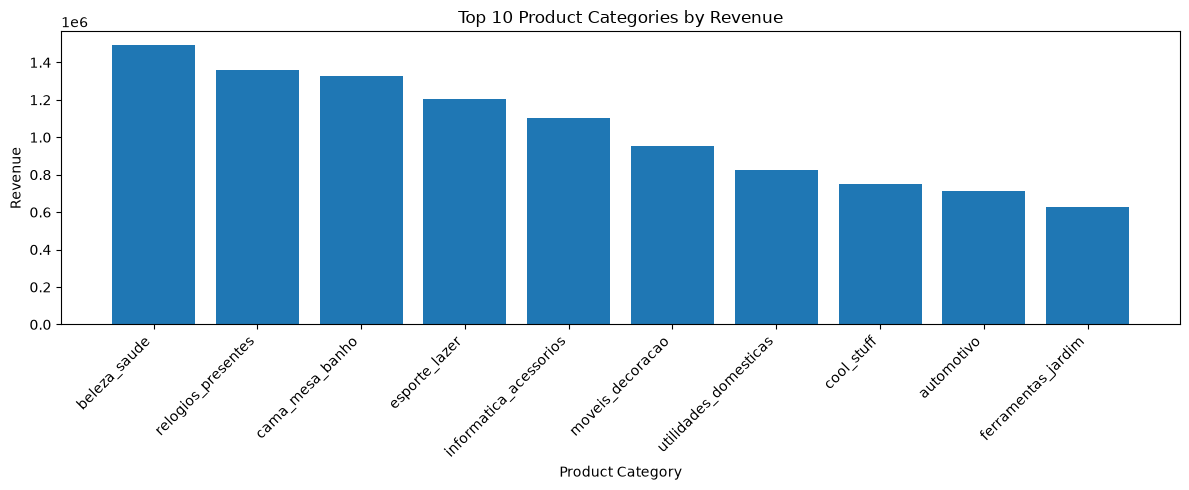

In [16]:
plt.figure(figsize=(12, 5))
plt.bar(
    top_categories_revenue["product_category_name"],
    top_categories_revenue["total_order_value"],
)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### 5.2 Top 10 catégories par nombre de commandes

In [17]:
top_categories_orders = (
    sales.groupby("product_category_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="orders")
)

top_categories_orders

,product_category_name,orders
0,cama_mesa_banho,9417
1,beleza_saude,8836
2,esporte_lazer,7720
3,informatica_acessorios,6689
4,moveis_decoracao,6449
5,utilidades_domesticas,5884
6,relogios_presentes,5624
7,telefonia,4199
8,automotivo,3897
9,brinquedos,3886


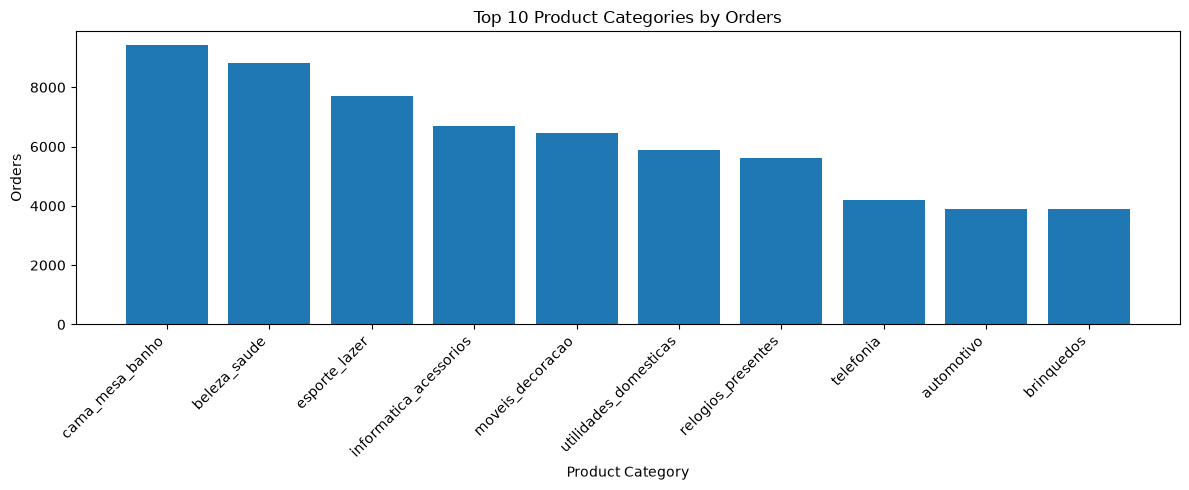

In [18]:
plt.figure(figsize=(12, 5))
plt.bar(top_categories_orders["product_category_name"], top_categories_orders["orders"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Product Categories by Orders")
plt.xlabel("Product Category")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

### 5.3 Panier moyen par catégorie

In [19]:
category_avg_basket = (
    sales.groupby("product_category_name")["total_order_value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="average_order_value")
)

category_avg_basket

,product_category_name,average_order_value
0,pcs,"1,151.70"
1,portateis_casa_forno_e_cafe,664.49
2,eletrodomesticos_2,503.50
3,agro_industria_e_comercio,360.35
4,instrumentos_musicais,320.69
5,eletroportateis,310.25
6,portateis_cozinha_e_preparadores_de_alimentos,285.22
7,telefonia_fixa,244.58
8,construcao_ferramentas_seguranca,230.99
9,moveis_quarto,220.18


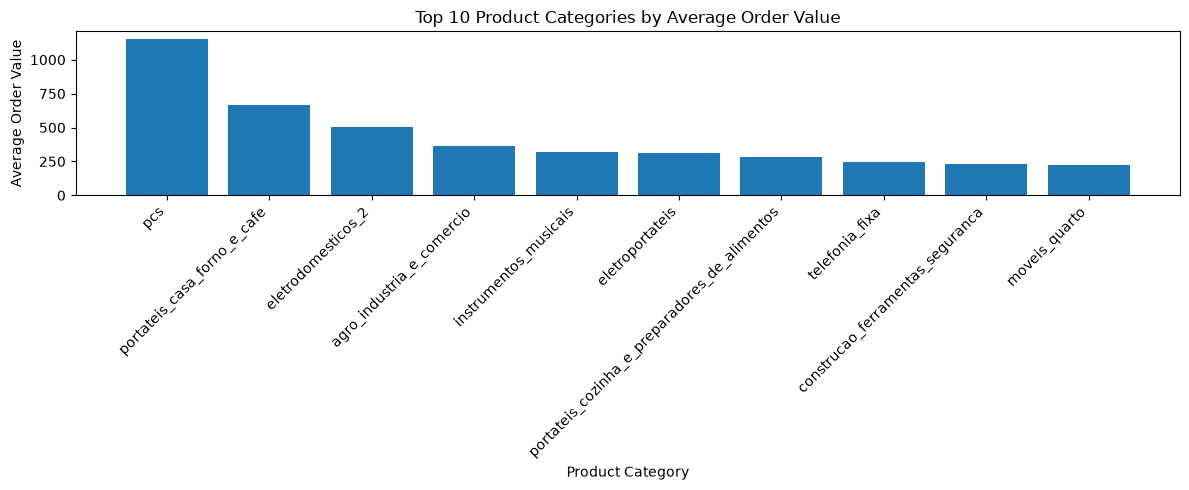

In [20]:
plt.figure(figsize=(12, 5))
plt.bar(
    category_avg_basket["product_category_name"],
    category_avg_basket["average_order_value"],
)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Product Categories by Average Order Value")
plt.xlabel("Product Category")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

### Business interpretation

Comparer le chiffre d'affaires, le volume de commandes et le panier moyen permet de distinguer :

- les catégories à fort volume ;
- les catégories à forte valeur ;
- les catégories prioritaires pour les campagnes commerciales.

## 6. Customer Analysis

### 6.1 Répartition des clients par État

In [21]:
customers_by_state = (
    sales.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="customers")
)

customers_by_state.head(10)

,customer_state,customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


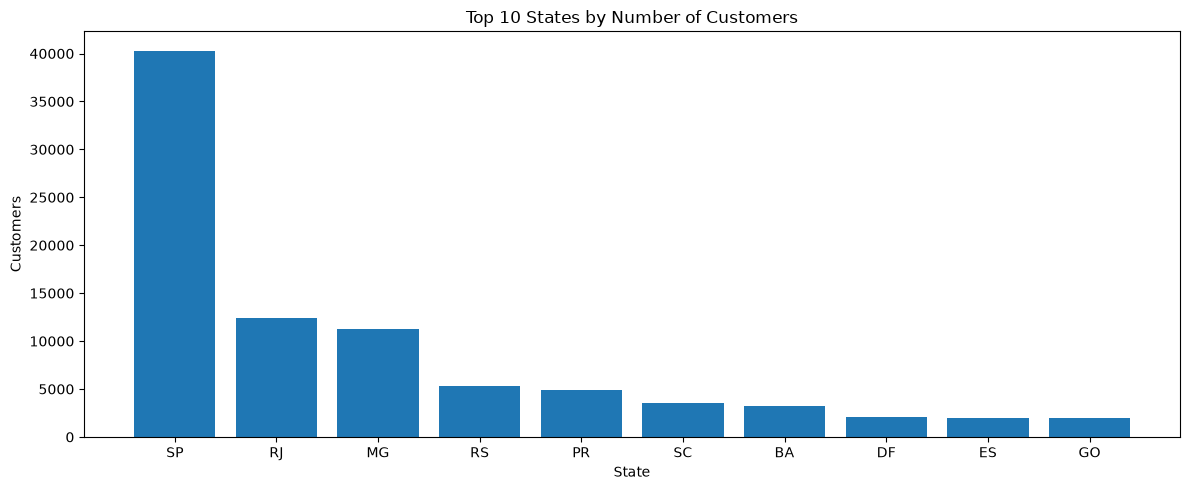

In [22]:
plt.figure(figsize=(12, 5))
plt.bar(
    customers_by_state.head(10)["customer_state"],
    customers_by_state.head(10)["customers"],
)
plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

### 6.2 Chiffre d'affaires par État client

In [23]:
revenue_by_state = (
    sales.groupby("customer_state")["total_order_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_state.head(10)

,customer_state,total_order_value
0,SP,"6,234,533.82"
1,RJ,"2,247,128.32"
2,MG,"1,928,571.09"
3,RS,"934,286.75"
4,PR,"832,059.40"
5,BA,"650,220.38"
6,SC,"632,514.14"
7,GO,"368,997.61"
8,DF,"367,750.15"
9,ES,"336,438.54"


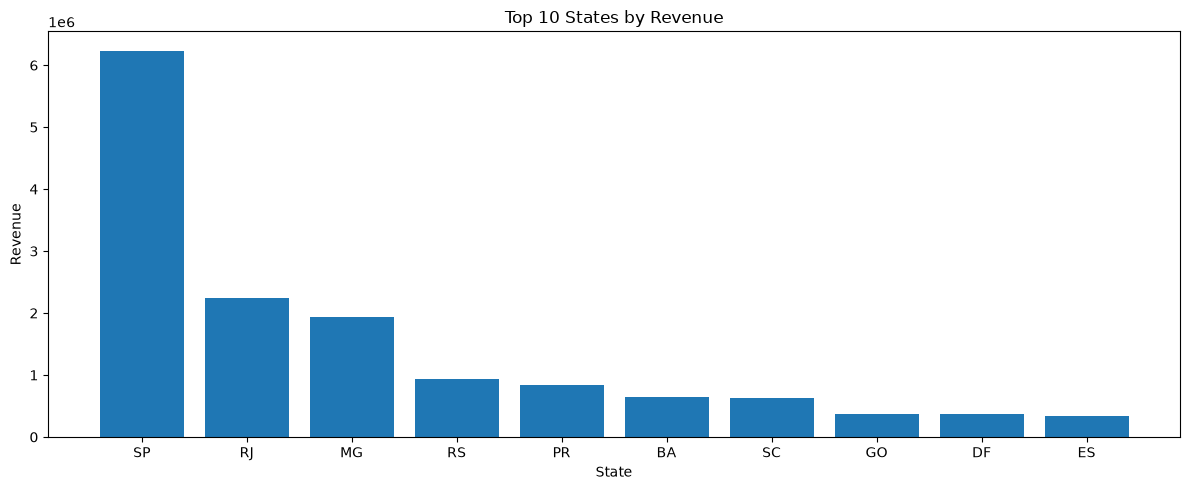

In [24]:
plt.figure(figsize=(12, 5))
plt.bar(
    revenue_by_state.head(10)["customer_state"],
    revenue_by_state.head(10)["total_order_value"],
)
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### 6.3 Clients récurrents vs clients uniques

In [25]:
customer_orders = (
    sales.groupby("customer_unique_id")["order_id"].nunique().reset_index(name="orders")
)

customer_orders["customer_type"] = np.where(
    customer_orders["orders"] > 1, "Repeat customer", "One-time customer"
)

customer_type_summary = (
    customer_orders.groupby("customer_type")["customer_unique_id"]
    .count()
    .reset_index(name="customers")
)

customer_type_summary

,customer_type,customers
0,One-time customer,93099
1,Repeat customer,2997


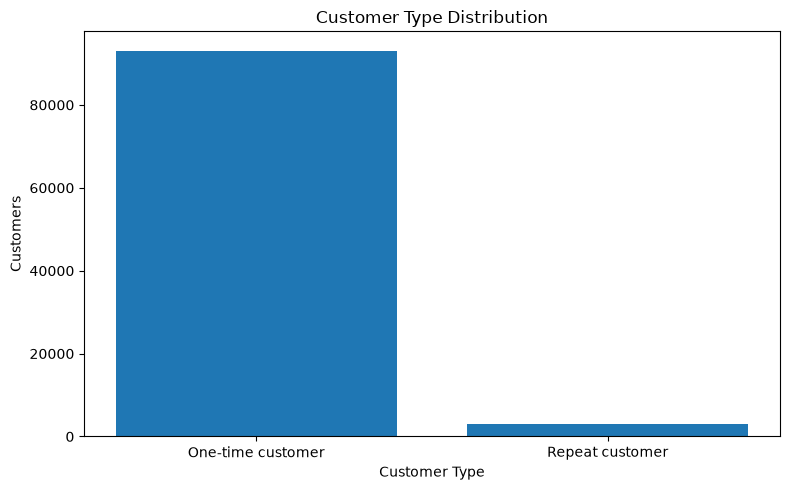

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(customer_type_summary["customer_type"], customer_type_summary["customers"])
plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

### Business interpretation

La part de clients récurrents permet d'évaluer la fidélité. Si la majorité des clients ne commande qu'une seule fois, l'entreprise peut travailler sur la rétention : e-mails post-achat, offres personnalisées, programme fidélité.

## 7. Logistics Analysis

### 7.1 Distribution du délai de livraison

In [27]:
delivery_stats = sales["delivery_time_days"].describe()
delivery_stats

count   115,722.00
mean         12.02
std           9.45
min           0.00
25%           6.00
50%          10.00
75%          15.00
max         209.00
Name: delivery_time_days, dtype: float64

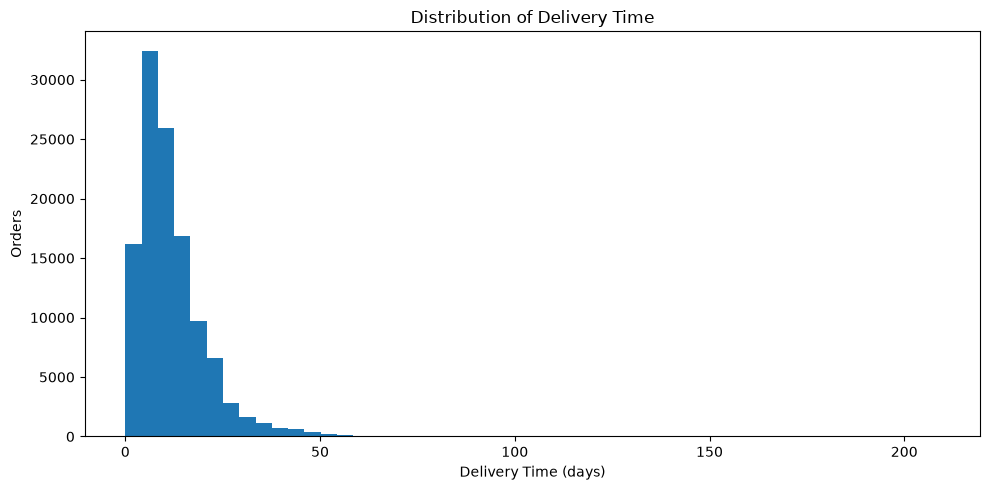

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(sales["delivery_time_days"].dropna(), bins=50)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

### 7.2 Taux de retard par État

In [29]:
delay_by_state = (
    sales.groupby("customer_state")["is_delayed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="delayed_rate_pct")
)

delay_by_state.head(10)

,customer_state,delayed_rate_pct
0,AL,20.47
1,MA,17.17
2,SE,15.14
3,PI,13.37
4,CE,12.91
5,BA,11.39
6,RJ,11.17
7,PA,10.81
8,PB,10.71
9,ES,10.47


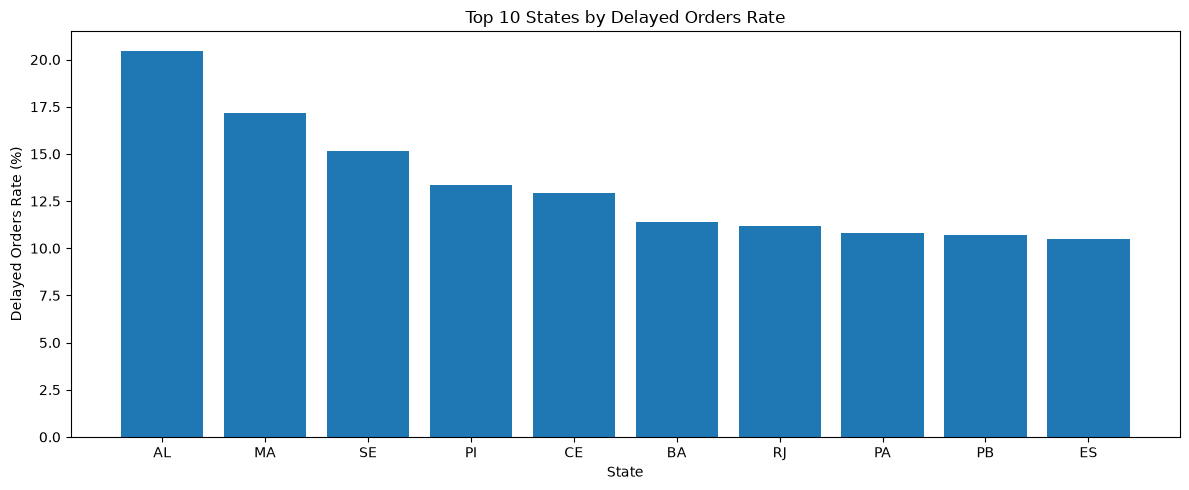

In [30]:
plt.figure(figsize=(12, 5))
plt.bar(
    delay_by_state.head(10)["customer_state"],
    delay_by_state.head(10)["delayed_rate_pct"],
)
plt.title("Top 10 States by Delayed Orders Rate")
plt.xlabel("State")
plt.ylabel("Delayed Orders Rate (%)")
plt.tight_layout()
plt.show()

### 7.3 Délai moyen de livraison par État

In [31]:
delivery_by_state = (
    sales.groupby("customer_state")["delivery_time_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="avg_delivery_time_days")
)

delivery_by_state.head(10)

,customer_state,avg_delivery_time_days
0,RR,27.83
1,AP,27.66
2,AM,26.06
3,AL,24.13
4,PA,23.27
5,MA,21.19
6,SE,20.89
7,CE,20.34
8,AC,20.17
9,PB,20.11


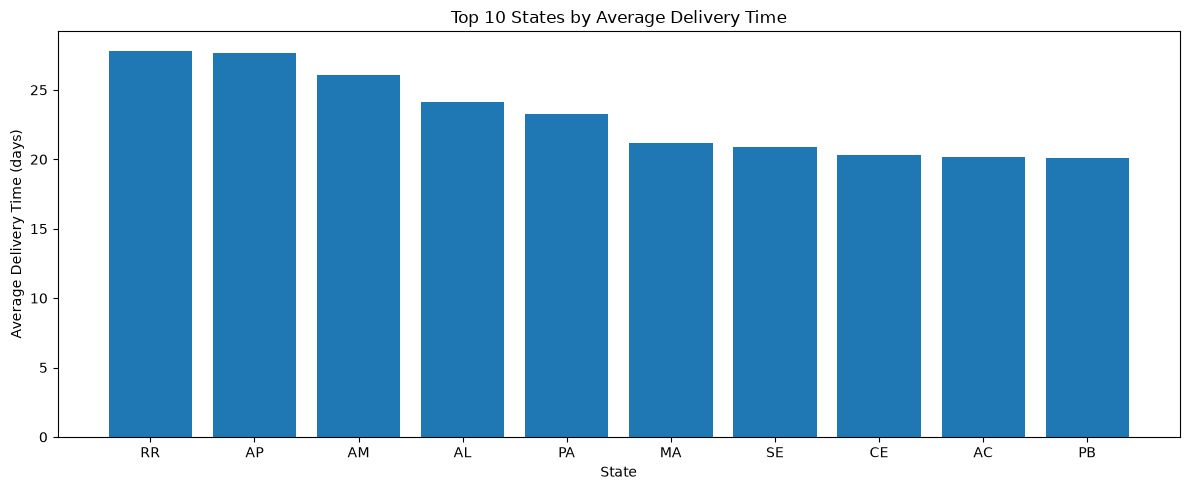

In [32]:
plt.figure(figsize=(12, 5))
plt.bar(
    delivery_by_state.head(10)["customer_state"],
    delivery_by_state.head(10)["avg_delivery_time_days"],
)
plt.title("Top 10 States by Average Delivery Time")
plt.xlabel("State")
plt.ylabel("Average Delivery Time (days)")
plt.tight_layout()
plt.show()

### Business interpretation

Les analyses logistiques permettent d'identifier les zones géographiques où la livraison est plus lente ou plus risquée. Ces informations peuvent guider l'amélioration du réseau de transport ou le choix de partenaires logistiques.

## 8. Seller Performance

### 8.1 Top vendeurs par chiffre d'affaires

In [33]:
seller_revenue = (
    sales.groupby("seller_id")
    .agg(
        revenue=("total_order_value", "sum"),
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        delayed_rate=("is_delayed", "mean"),
    )
    .reset_index()
)

seller_revenue["delayed_rate"] = seller_revenue["delayed_rate"] * 100

seller_revenue.sort_values("revenue", ascending=False).head(10)

,seller_id,revenue,orders,avg_review,delayed_rate
1013,53243585a1d6dc2643021fd1853d8905,"258,882.28",358,4.07,2.75
857,4869f7a5dfa277a7dca6462dcf3b52b2,"258,625.52",1132,4.11,11.05
1535,7c67e1448b00f6e969d365cea6b010ab,"254,387.70",982,3.39,8.54
881,4a3ca9315b744ce9f8e9374361493884,"253,535.64",1806,3.80,9.19
3024,fa1c13f2614d7b5c4749cbc52fecda94,"214,454.82",585,4.34,9.20
2643,da8622b14eb17ae2831f4ac5b9dab84a,"198,621.24",1314,4.07,6.02
1560,7e93a43ef30c4f03f38b393420bc753a,"189,475.90",336,4.21,4.26
192,1025f0e2d44d7041d6cf58b6550e0bfa,"178,696.05",915,3.86,6.57
1505,7a67c85e85bb2ce8582c35f2203ad736,"172,887.23",1160,4.23,4.98
1824,955fee9216a65b617aa5c0531780ce60,"163,275.71",1287,4.05,6.41


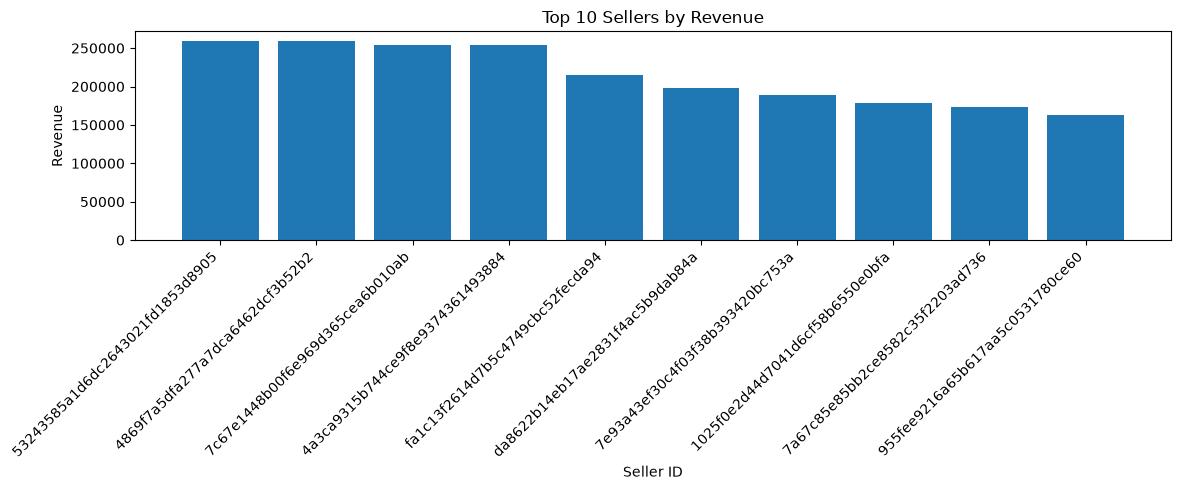

In [34]:
top_sellers = seller_revenue.sort_values("revenue", ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_sellers["seller_id"], top_sellers["revenue"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### 8.2 Vendeurs à risque

On identifie les vendeurs ayant un volume suffisant mais un taux de retard élevé.

In [35]:
seller_risk = seller_revenue[seller_revenue["orders"] >= 50].copy()

seller_risk = seller_risk.sort_values("delayed_rate", ascending=False)

seller_risk.head(10)

,seller_id,revenue,orders,avg_review,delayed_rate
1032,54965bbe3e4f07ae045b90b0b8541f52,"13,469.92",78,2.94,30.68
492,2a1348e9addc1af5aaa619b1a3679d6b,"3,631.40",52,3.00,27.27
2257,bbad7e518d7af88a0897397ffdca1979,"5,857.95",69,3.06,22.09
2298,beadbee30901a7f61d031b6b686095ad,"5,311.52",64,3.94,22.06
1180,6039e27294dc75811c0d8a39069f52c0,"18,195.12",64,3.89,21.52
494,2a261b5b644fa05f4f2700eb93544f2c,"7,628.35",51,3.35,20.24
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,"10,976.94",98,2.95,20.00
163,0d85bbda9889ce1f7e63778d24f346eb,"6,640.02",51,4.17,20.00
81,06a2c3af7b3aee5d69171b0e14f0ee87,"49,070.97",392,3.99,19.27
2458,cac4c8e7b1ca6252d8f20b2fc1a2e4af,"6,714.37",75,3.44,18.95


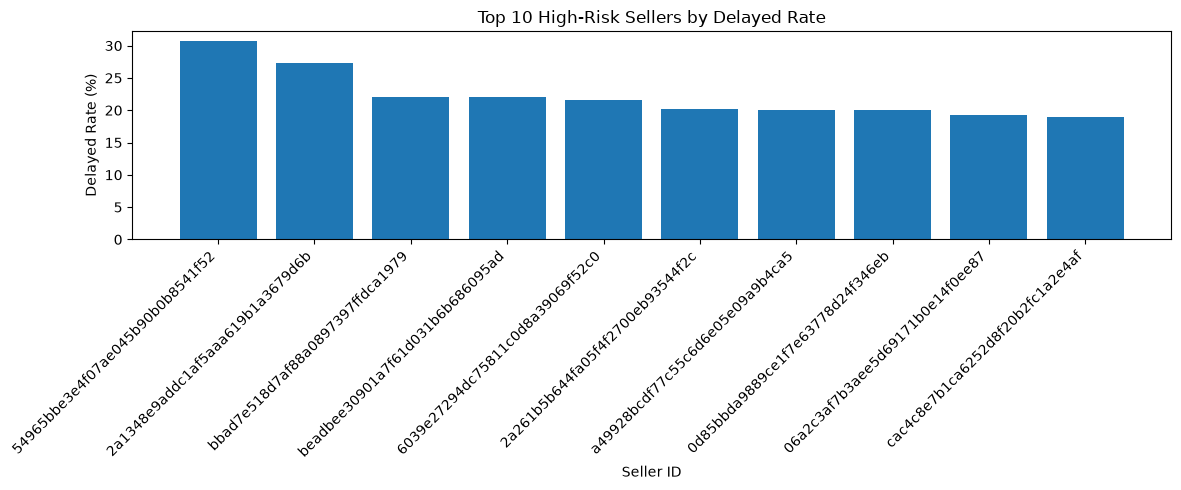

In [36]:
plt.figure(figsize=(12, 5))
plt.bar(seller_risk.head(10)["seller_id"], seller_risk.head(10)["delayed_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 High-Risk Sellers by Delayed Rate")
plt.xlabel("Seller ID")
plt.ylabel("Delayed Rate (%)")
plt.tight_layout()
plt.show()

### Business recommendation

Les vendeurs avec un fort volume et un taux de retard élevé doivent être suivis prioritairement. Un plan d'action peut inclure : audit logistique, revue des délais de préparation, ajustement des SLA et accompagnement opérationnel.

## 9. Customer Satisfaction

### 9.1 Distribution des notes clients

In [37]:
review_distribution = (
    sales.groupby("review_score")["order_id"].nunique().reset_index(name="orders")
)

review_distribution

,review_score,orders
0,1.00,11393
1,2.00,3148
2,3.00,8160
3,4.00,19098
4,5.00,57076


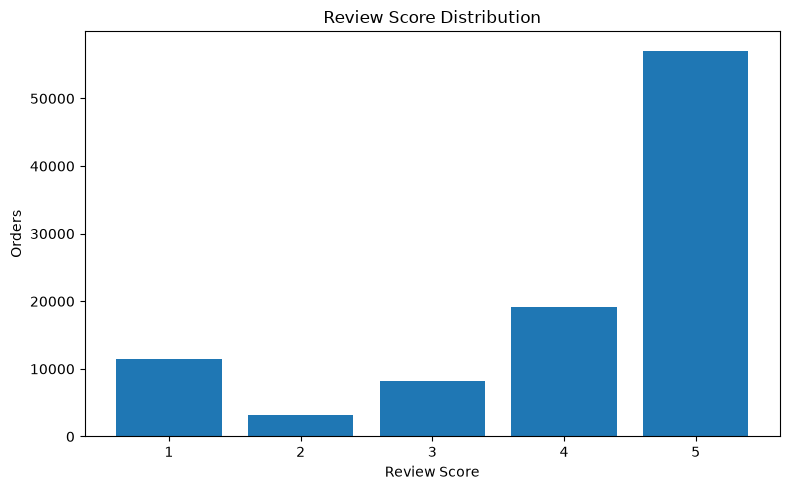

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(review_distribution["review_score"], review_distribution["orders"])
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Orders")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

### 9.2 Impact du retard sur la satisfaction

In [39]:
review_delay = sales.groupby("is_delayed")["review_score"].mean().reset_index()

review_delay["delivery_status"] = review_delay["is_delayed"].map(
    {0: "On time or early", 1: "Delayed"}
)
review_delay

,is_delayed,review_score,delivery_status
0,0,4.13,On time or early
1,1,2.25,Delayed


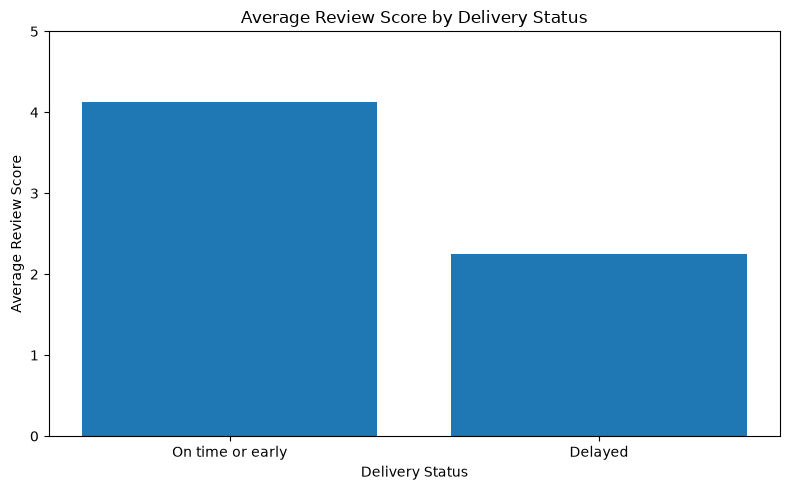

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(review_delay["delivery_status"], review_delay["review_score"])
plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

### 9.3 Satisfaction par catégorie

In [41]:
category_satisfaction = (
    sales.groupby("product_category_name")
    .agg(avg_review=("review_score", "mean"), orders=("order_id", "nunique"))
    .query("orders >= 100")
    .sort_values("avg_review")
    .reset_index()
)

category_satisfaction.head(10)

,product_category_name,avg_review,orders
0,moveis_escritorio,3.53,1273
1,fashion_roupa_masculina,3.55,112
2,telefonia_fixa,3.67,217
3,audio,3.84,350
4,construcao_ferramentas_seguranca,3.85,167
5,cama_mesa_banho,3.89,9417
6,casa_conforto,3.91,397
7,moveis_decoracao,3.91,6449
8,moveis_sala,3.91,422
9,artes,3.94,202


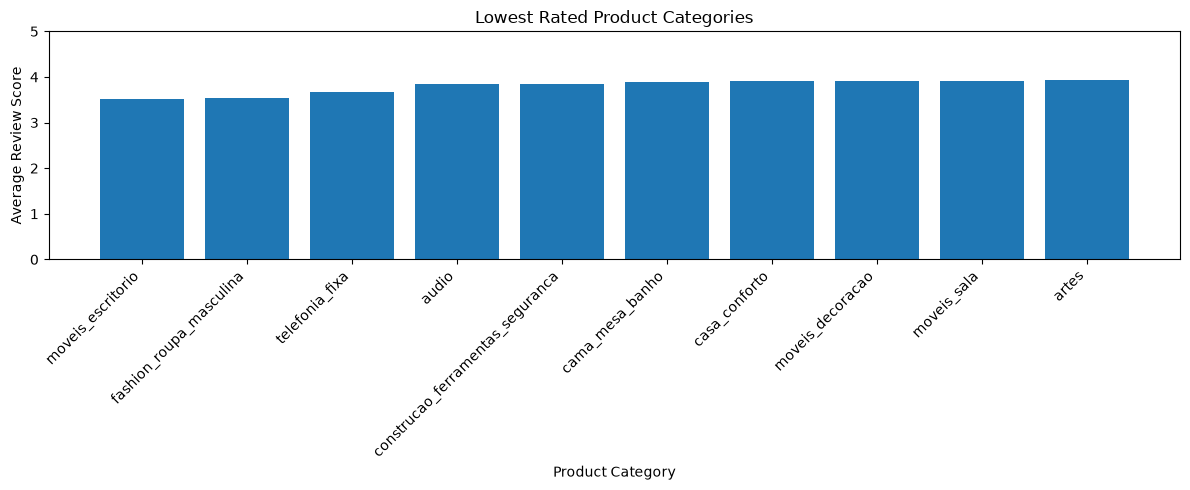

In [42]:
plt.figure(figsize=(12, 5))
plt.bar(
    category_satisfaction.head(10)["product_category_name"],
    category_satisfaction.head(10)["avg_review"],
)
plt.xticks(rotation=45, ha="right")
plt.title("Lowest Rated Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

### Business interpretation

La comparaison entre les commandes livrées en retard et non retardées permet de mesurer l'impact opérationnel sur la satisfaction client. Si la note moyenne diminue fortement en cas de retard, la réduction des retards devient un levier direct d'amélioration de l'expérience client.

## 10. Préparation des tables pour Power BI

Pour faciliter la création du dashboard, on exporte plusieurs tables agrégées.

In [43]:
POWERBI_DATA = DATA_PROCESSED / "powerbi_exports"
POWERBI_DATA.mkdir(exist_ok=True)

monthly_revenue.to_csv(POWERBI_DATA / "monthly_revenue.csv", index=False)
monthly_orders.to_csv(POWERBI_DATA / "monthly_orders.csv", index=False)
top_categories_revenue.to_csv(POWERBI_DATA / "top_categories_revenue.csv", index=False)
revenue_by_state.to_csv(POWERBI_DATA / "revenue_by_state.csv", index=False)
delay_by_state.to_csv(POWERBI_DATA / "delay_by_state.csv", index=False)
seller_revenue.to_csv(POWERBI_DATA / "seller_performance.csv", index=False)
review_distribution.to_csv(POWERBI_DATA / "review_distribution.csv", index=False)

print("Power BI export files created successfully.")

Power BI export files created successfully.


## 11. Conclusions & recommandations business

In [44]:
summary = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Total Customers": total_customers,
    "Average Order Value": avg_order_value,
    "Delayed Orders Rate (%)": delayed_rate,
    "Average Review Score": avg_review_score,
    "Average Delivery Time (days)": avg_delivery_time,
    "Top Revenue Category": top_categories_revenue.iloc[0]["product_category_name"],
    "Top Revenue State": revenue_by_state.iloc[0]["customer_state"],
}

pd.DataFrame(summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Total Revenue,"16,643,731.30"
1,Total Orders,99441
2,Total Customers,96096
3,Average Order Value,167.37
4,Delayed Orders Rate (%),6.34
5,Average Review Score,4.02
6,Average Delivery Time (days),12.02
7,Top Revenue Category,beleza_saude
8,Top Revenue State,SP


### Key insights

1. **Sales performance** : le chiffre d'affaires et le volume de commandes permettent d'identifier les périodes les plus importantes pour l'activité.
2. **Product performance** : certaines catégories concentrent une part importante du chiffre d'affaires et doivent être suivies prioritairement.
3. **Customer geography** : certains États génèrent davantage de clients et de revenus, ce qui peut orienter les investissements marketing.
4. **Logistics** : les retards de livraison restent un indicateur clé à suivre car ils peuvent impacter directement la satisfaction client.
5. **Seller performance** : certains vendeurs combinent volume élevé et taux de retard important, ce qui représente un risque opérationnel.

### Business recommendations

- Prioriser les catégories les plus rentables dans les campagnes commerciales.
- Surveiller les vendeurs à fort volume ayant un taux de retard élevé.
- Optimiser la logistique dans les États où les délais moyens sont les plus longs.
- Mettre en place un suivi Power BI mensuel des KPI : CA, commandes, panier moyen, retard, satisfaction.
- Croiser les données de retard avec les notes clients pour quantifier l'impact de la livraison sur l'expérience client.